## Analysis of Results

#### Setup

In [7]:
### Imports ###
import os
import shutil
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.lines as mlines
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path
from scipy.stats import norm, qmc
import SALib
from SALib.sample import sobol
from SALib.analyze import sobol 
from eppy.modeleditor import IDF


In [2]:
work_dir = "/jumbo/keller-lab/Jeremy_Wang/eplus_sa/scripts/main" # Change this to your working directory
idd_file_path = "/jumbo/keller-lab/Applications/EnergyPlus-24-1-0/Energy+.idd" # Change to your IDD file path
base_output_idf_dir = os.path.join(work_dir, "randomized_idfs_sobol") # change base output to sobol sequence generated
weather_file = os.path.join(
    work_dir, "weather_data",
    "USA_IL_Chicago-OHare-Intl-AP.725300_AMY_2023.epw"
)
base_output_sim_dir = os.path.join(work_dir, "output_sobol") # output_sobol stores values
os.chdir(work_dir) # Set working directory

### Load Simulation Results for all seeds

In [3]:
# number of sims per seed
num_simulations = 30000

# list your seed directories
seeds = [f"seed_{i}" for i in range(1,6)]

# where your outputs live
output_base = os.path.join(work_dir, "output_sobol")

def read_csv_for_sim(task):
    seed, sim_id = task
    folder = f"randomized_{sim_id}" # sim id is number run within the seed
    csv_file = os.path.join(output_base, seed, folder, "eplusmtr.csv")
    # skip if missing or zero‐byte
    if not os.path.isfile(csv_file) or os.path.getsize(csv_file) == 0:
        return None
    try:
        df = pd.read_csv(csv_file)
    except pd.errors.EmptyDataError:
        return None
    df["Simulation_ID"] = sim_id
    df["seed"]          = seed
    return df

#### Checking to see where files are missing

In [4]:
# build the full list of (seed, sim_id) pairs
tasks = [(seed, i) for seed in seeds for i in range(1, num_simulations+1)]

max_workers = os.cpu_count() or 4 # returns the number of available cpu cores
print(f"Reading {len(tasks)} files across {len(seeds)} seeds using {max_workers} workers...")

# checking which files are missing
missing_files = pd.DataFrame(columns = ['seed', 'sim_id'])
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    future_to_task = {executor.submit(read_csv_for_sim, t): t for t in tasks} # for every task (seed, i) combo, tells the executor to read csv
    for future in as_completed(future_to_task): # as soon as completed, append df into a bigger output
        df = future.result()
        seed, sim_id = future_to_task[future]
        if df is None:
            new_row = pd.DataFrame([{'seed': seed, 'sim_id': sim_id}])
            missing_files = pd.concat([missing_files, new_row], ignore_index=True)
            print(f"Skipping empty/missing file: {seed}/randomized_{sim_id}/eplusmtr.csv")

if missing_files.empty:
    print("No missing files detected.")


Reading 150000 files across 5 seeds using 64 workers...
Skipping empty/missing file: seed_1/randomized_7056/eplusmtr.csv
Skipping empty/missing file: seed_1/randomized_7241/eplusmtr.csv
Skipping empty/missing file: seed_2/randomized_1882/eplusmtr.csv
Skipping empty/missing file: seed_4/randomized_8891/eplusmtr.csv
Skipping empty/missing file: seed_4/randomized_28116/eplusmtr.csv


In [5]:
missing_files 

,seed,sim_id
0,seed_1,7056
1,seed_1,7241
2,seed_2,1882
3,seed_4,8891
4,seed_4,28116


In [9]:
# --- Simulation function ---
# output_idf_dir is the location where the idf is currently stored
# output_sim_dir is where the outputs are saved to
def run_single_simulation(idf_file, output_idf_dir, output_sim_dir):
    # Ensure EnergyPlus IDD
    IDF.setiddname(idd_file_path)
    # Create per-model output folder
    case_name = os.path.splitext(idf_file)[0]
    sim_dir = os.path.join(output_sim_dir, case_name)

    # Remove existing sim_dir if it exists to avoid conflicts
    if os.path.exists(sim_dir):
        shutil.rmtree(sim_dir)
    os.makedirs(sim_dir, exist_ok=True)

    # Load and save a validated copy (saving a copy of the idf in the output folder)
    src = os.path.join(output_idf_dir, idf_file)
    idf = IDF(src)
    validated = os.path.join(sim_dir, idf_file)
    idf.save(validated)
    # Run EnergyPlus
    subprocess.run([
        '/jumbo/keller-lab/Applications/EnergyPlus-24-1-0/energyplus',
        '--weather', weather_file,
        '--output-directory', sim_dir,
        '--idd', idd_file_path,
        # annual indicates annual run, readvars processes outputs
        '--annual', '--readvars', validated # validated is the idf
    ], check=True)


for i in range(len(missing_files)):
    seed = missing_files.iloc[i]['seed']
    file = missing_files.iloc[i]['sim_id']
    idf_file = f"randomized_{file}.idf"
    output_idf_dir = os.path.join(base_output_idf_dir, f"{seed}")
    output_sim_dir = os.path.join(base_output_sim_dir, f"{seed}")

    run_single_simulation(idf_file, output_idf_dir, output_sim_dir)
    print(f"Completed simulation for {idf_file} in {seed}")


EnergyPlus Starting
EnergyPlus, Version 24.1.0-9d7789a3ac, YMD=2026.02.18 15:48
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=01/21/2023
Continuing Simulation at 01/21/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=02/10/2023
Continuing Simulation at 02/10/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/02/2023
Continuing Simulation at 03/02/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/22/2023
Continuing Simulation at 03/22/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=04/11/2023
Continuing Simulation at 04/11/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=05/01/2023
C

EnergyPlus Completed Successfully.


Completed simulation for randomized_7056.idf in seed_1
EnergyPlus Starting
EnergyPlus, Version 24.1.0-9d7789a3ac, YMD=2026.02.18 15:49
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=01/21/2023
Continuing Simulation at 01/21/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=02/10/2023
Continuing Simulation at 02/10/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/02/2023
Continuing Simulation at 03/02/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/22/2023
Continuing Simulation at 03/22/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=04/11/2023
Continuing Simulation at 04/11/2023 for RUN PERIOD 1
U

EnergyPlus Completed Successfully.


Completed simulation for randomized_7241.idf in seed_1
EnergyPlus Starting
EnergyPlus, Version 24.1.0-9d7789a3ac, YMD=2026.02.18 15:49
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=01/21/2023
Continuing Simulation at 01/21/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=02/10/2023
Continuing Simulation at 02/10/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/02/2023
Continuing Simulation at 03/02/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/22/2023
Continuing Simulation at 03/22/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=04/11/2023
Continuing Simulation at 04/11/2023 for RUN PERIOD 1
U

EnergyPlus Completed Successfully.


Completed simulation for randomized_1882.idf in seed_2
EnergyPlus Starting
EnergyPlus, Version 24.1.0-9d7789a3ac, YMD=2026.02.18 15:49
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=01/21/2023
Continuing Simulation at 01/21/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=02/10/2023
Continuing Simulation at 02/10/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/02/2023
Continuing Simulation at 03/02/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/22/2023
Continuing Simulation at 03/22/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=04/11/2023
Continuing Simulation at 04/11/2023 for RUN PERIOD 1
U

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 24.1.0-9d7789a3ac, YMD=2026.02.18 15:49
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=01/21/2023
Continuing Simulation at 01/21/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=02/10/2023
Continuing Simulation at 02/10/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/02/2023
Continuing Simulation at 03/02/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=03/22/2023
Continuing Simulation at 03/22/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=04/11/2023
Continuing Simulation at 04/11/2023 for RUN PERIOD 1
Updating Shadowing Calculations, Start Date=05/01/2023
C

EnergyPlus Completed Successfully.


### Loading Simulation Results ###

In [10]:

all_dfs = []
tasks = [(seed, i) for seed in seeds for i in range(1, num_simulations+1)]
max_workers = os.cpu_count() or 4 # returns the number of available cpu cores

with ProcessPoolExecutor(max_workers=max_workers) as executor:
    future_to_task = {executor.submit(read_csv_for_sim, t): t for t in tasks} # for every task (seed, i) combo, tells the executor to read csv
    for future in as_completed(future_to_task): # as soon as completed, append df into a bigger output
        df = future.result()
        seed, sim_id = future_to_task[future]
        if df is not None:
            all_dfs.append(df)

# combine into one big DataFrame
# # rows = ((num_simulations * num_seeds) - (missing files)) * 12 months
combined_df = pd.concat(all_dfs, ignore_index=True)

In [11]:
analysis_sim_dir = os.path.join(work_dir, "analysis_sobol")
os.makedirs(analysis_sim_dir, exist_ok=True)

# --- Clean analysis output directory ---
for fn in os.listdir(analysis_sim_dir):
    path = os.path.join(analysis_sim_dir, fn)
    if os.path.isfile(path) or os.path.islink(path): 
        os.unlink(path)
    elif os.path.isdir(path):
        shutil.rmtree(path)

# --- CSV output directory ---
csv_out = os.path.join(analysis_sim_dir, "output_csv")
if os.path.isdir(csv_out): shutil.rmtree(csv_out) # removing the folder if it already exists
os.makedirs(csv_out, exist_ok=True)

In [12]:
### Convert numbers into numerics ###

# Convert columns to numeric
numeric_cols = [
    "Electricity:Facility [J](Monthly)", "Electricity:Building [J](Monthly)", "InteriorLights:Electricity [J](Monthly)",
    "Electricity:Facility [J](RunPeriod)", "Electricity:Building [J](RunPeriod)", "InteriorLights:Electricity [J](RunPeriod)",
    "Electricity:HVAC [J](Monthly)", "NaturalGas:Facility [J](Monthly)", "NaturalGas:HVAC [J](Monthly)",
    "Electricity:HVAC [J](RunPeriod)", "NaturalGas:Facility [J](RunPeriod)", "NaturalGas:HVAC [J](RunPeriod)"
]

for col in numeric_cols:
    if col in combined_df:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

# Unit conversions (adds columns in KJ, KWh, BTU)
for col in list(combined_df):
    if col.endswith("[J](Monthly)") or col.endswith("[J](RunPeriod)"):
        combined_df[col.replace("[J]", "[KJ]")] = combined_df[col] / 1e3
        combined_df[col.replace("[J]", "[kWh]")] = combined_df[col] / 3.6e6

BTU_conv = 0.000947817
for col in list(combined_df):
    if "[J](" in col and ("HVAC" in col or "NaturalGas" in col):
        combined_df[col.replace("[J]", "[BTU]")] = combined_df[col] * BTU_conv

# saving converted combined_df values to csv in the folder
combined_df.to_csv(os.path.join(csv_out, "combined_sims.csv"), index=False, float_format="%.2f")

# --- Define month order ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

combined_df["Date/Time"] = pd.Categorical(
    combined_df["Date/Time"], categories=month_order, ordered=True
)

In [13]:
### saving csv files by seed ###

# For a variable number of seeds (e.g., 1 to 20)
max_seed = 5  # Change this to the number of seeds you have

for i in range(1, max_seed + 1):
    seed_name = f"seed_{i}"
    # Check if this seed exists in the data before creating the variable
    if seed_name in combined_df["seed"].unique():
        globals()[seed_name] = combined_df[combined_df["seed"] == seed_name] # creates a df for each seed

for i in range(1, max_seed+1):
    seed_df = combined_df[combined_df["seed"] == f"seed_{i}"]
    seed_df.to_csv(
        os.path.join(csv_out, f"seed_{i}.csv"),
        index=False,
        float_format="%.2f"
    )

### Calculate annual energy consumption ###

In [14]:

# note: the column electricity: facility [J] is total electricity consumption for the month
total_consumption_cols = ['Electricity:Facility [J](Monthly)', 'Electricity:Facility [KJ](Monthly)','Electricity:Facility [kWh](Monthly)','Simulation_ID', 'seed',]
total_consumption = combined_df[total_consumption_cols]

# summing up monthly consumption to annual consumption per simulation
annual_consumption = (
    total_consumption
    .groupby(['Simulation_ID','seed'], as_index=False)
    .agg(
        seed = ('seed', 'first'),
        **{
            col: (col, 'sum')
            for col in total_consumption_cols
            if col not in ['Simulation_ID', 'seed']
        }
    )
)

# order by seed and Simulation_ID
annual_consumption = annual_consumption.sort_values(
    by=['seed', 'Simulation_ID']
).reset_index(drop=True)

# renaming columns from monthly to annual
annual_consumption = annual_consumption.rename(
    columns=lambda c: c.replace('(Monthly)', '(Annual)')
)

### Calculate Sensitivity Indices ###

In [35]:


# generate problem dictionary for SALib 
# exclude cooling setpoint, add gap
parameter_names = ['heating_setpoint', 'people_per_area', 'infil_flow_rate_living',
                   'infil_flow_rate_garage', 'infil_flow_rate_attic', 'watts_equip', 'watts_lights', 'heating_COP',
                   'fan_efficiency', 'pressure_rise', 'solar_transmittance', 'burner_eff', 'vent_flow_rate','gap']

problem = {
        'num_vars': len(parameter_names),
        'names': parameter_names,
        'bounds': [[0.0, 1.0]] * len(parameter_names) # generating uniform distribution from 0 to 1
    }

# create a dictionary for each seed and list corresponding
# for now, we focus on the annual outputs in KJ
outputs_KJ = {}
for i in range(1,max_seed+1):
    seed_name = f"seed_{i}"
    outputs_KJ[seed_name] = annual_consumption.loc[annual_consumption['seed'] == seed_name, ['Simulation_ID','Electricity:Facility [KJ](Annual)']].to_numpy()

# calculate sobol indices for seed 1-5, first and total order
# second order requires more samples than current available (N=30000), we need extra samples to calculate second order indices
sobol_indices = {}
Nboot = 200
for i in range(1, max_seed+1):
    seed_name = f"seed_{i}"
    sobol_indices[seed_name] = sobol.analyze(
        problem,
        outputs_KJ[seed_name][:,1], # the second column is the output variable (electricity consumption in KJ)
        calc_second_order=True,
        # resamples used for convergence
        num_resamples=Nboot,
        keep_resamples = True
    )

/jumbo/keller-lab/Applications/mambaforge/envs/eplus/lib/python3.9/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [27]:
len(sobol_indices['seed_1']['ST_conf_all'][0])

14

### Creating rankings of parameters ###


In [16]:
si_ranks = {}
for i in range(1, max_seed+1):
    seed_name = f"seed_{i}"
    df = pd.DataFrame({
        "seed": seed_name,
        "parameter": problem["names"],
        "S1": sobol_indices[seed_name]["S1"],
        "ST": sobol_indices[seed_name]["ST"],
        "S1_conf": sobol_indices[seed_name]["S1_conf"],
        "ST_conf": sobol_indices[seed_name]["ST_conf"]
    })
    
    # Assign ranks: highest ST/S1 gets rank 1
    df["ST_rank"] = df["ST"].rank(ascending=False, method="min").astype(int)
    df["S1_rank"] = df["S1"].rank(ascending=False, method="min").astype(int)
    
    si_ranks[seed_name] = df


### Generating plots for visualization


In [17]:
# combine all seeds into one dataframe for plotting

dfs = []

for seed, seed_df in si_ranks.items():
    df = seed_df.copy()   # never mutate originals
    dfs.append(df)

# concatonate
df_all = pd.concat(dfs, ignore_index=True)

# filter out certain parameters
filter_hs_gap = df_all[~df_all['parameter'].isin(['heating_setpoint', 'gap'])]
filter_hs_gap_COP = df_all[~df_all['parameter'].isin(['heating_setpoint', 'gap', 'heating_COP'])]


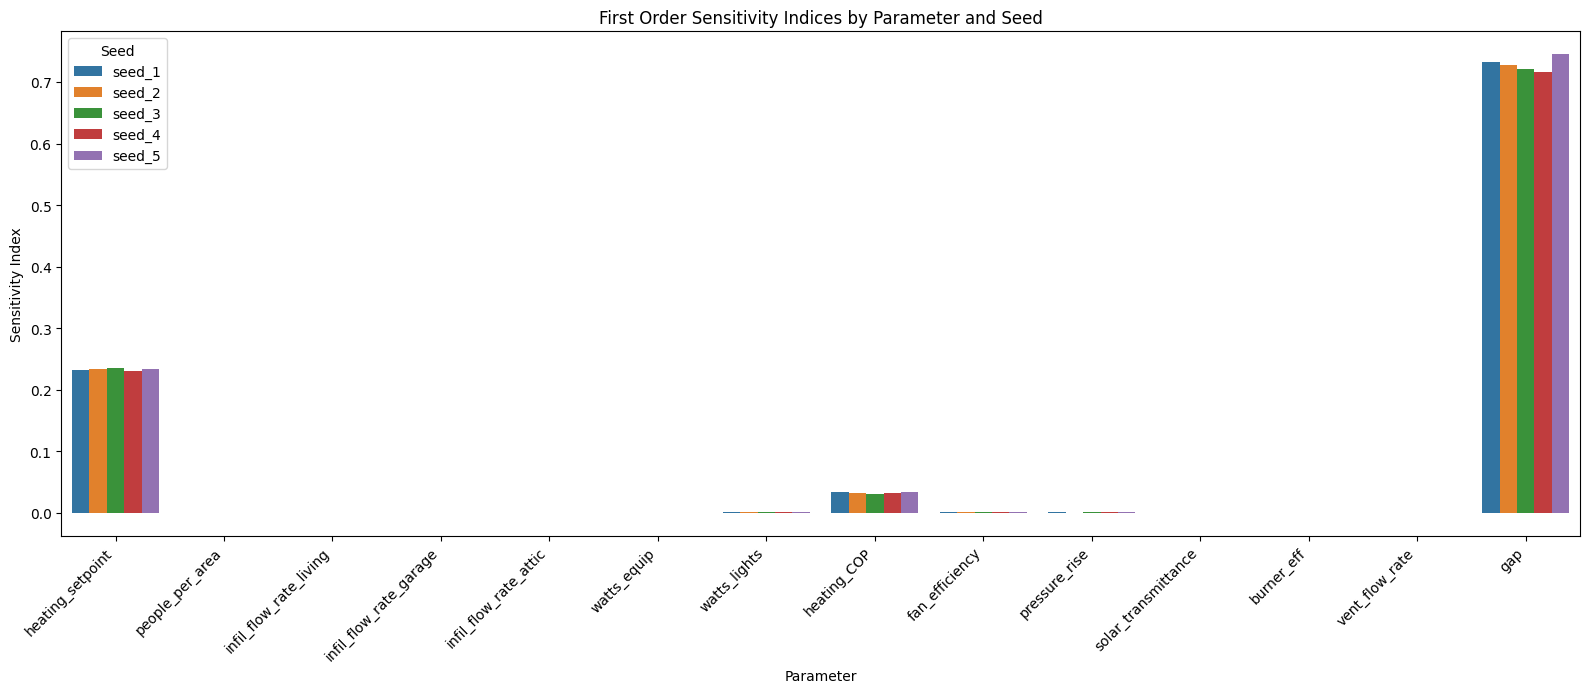

In [18]:
### First Order Sensitivity Indices Plot ### 
def plot_first_order_sensitivity_indices(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    # Seed order
    seed_order = sorted(si_ranks.keys())

    df["seed"] = pd.Categorical(
        df["seed"],
        categories=seed_order,
        ordered=True
    )

    plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="S1",
        hue="seed",
        errorbar=None
    )

    # confidence intervals
    # bars = ax.patches

    # for bar, (_, row) in zip(bars, df_all.iterrows()):
    #     x = bar.get_x() + bar.get_width() / 2
    #     y = row["S1"]

    #     ax.errorbar(
    #         x,
    #         y,
    #         yerr=row["S1_conf"],   
    #         fmt="none",
    #         ecolor="black",
    #         capsize=3,
    #         linewidth=1
    #     )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("First Order Sensitivity Indices by Parameter and Seed")
    plt.legend(title="Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.show()

plot_first_order_sensitivity_indices(df_all)
# plot_first_order_sensitivity_indices(filter_hs_gap)
# plot_first_order_sensitivity_indices(filter_hs_gap_COP)

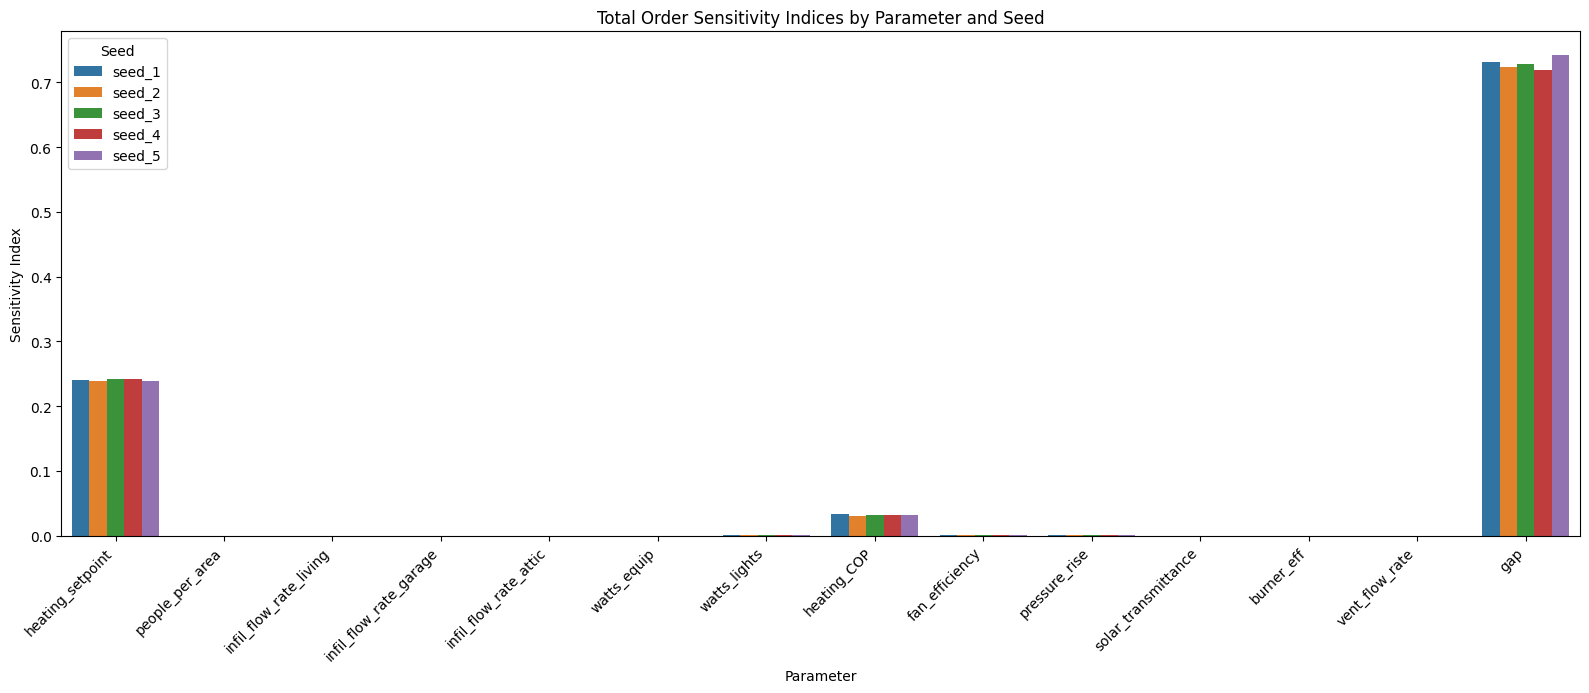

/tmp/ipykernel_181983/3265423682.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["parameter"] = pd.Categorical(
/tmp/ipykernel_181983/3265423682.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["seed"] = pd.Categorical(


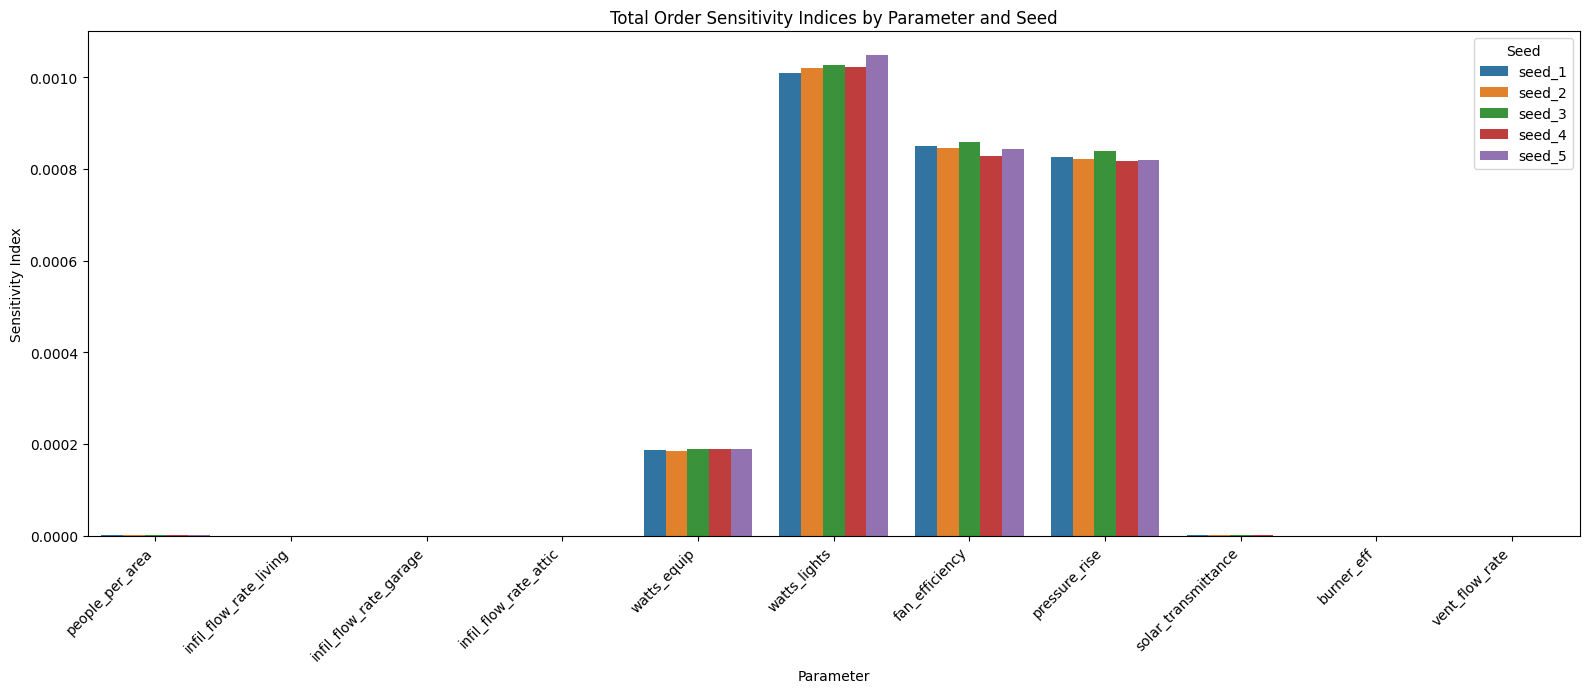

In [19]:
### Total Order Sensitivity Indices Plot ### 
def plot_total_order_sensitivity_indices(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    # Seed order
    seed_order = sorted(si_ranks.keys())

    df["seed"] = pd.Categorical(
        df["seed"],
        categories=seed_order,
        ordered=True
    )

    plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="ST",
        hue="seed",
        errorbar=None
    )

    # confidence intervals
    # bars = ax.patches

    # for bar, (_, row) in zip(bars, df.iterrows()):
    #     x = bar.get_x() + bar.get_width() / 2
    #     y = row["ST"]

    #     ax.errorbar(
    #         x,
    #         y,
    #         yerr=row["ST_conf"],   
    #         fmt="none",
    #         ecolor="black",
    #         capsize=3,
    #         linewidth=1
    #     )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("Total Order Sensitivity Indices by Parameter and Seed")
    plt.legend(title="Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.show()

plot_total_order_sensitivity_indices(df_all)
# # plot_total_order_sensitivity_indices(filter_hs_gap)
plot_total_order_sensitivity_indices(filter_hs_gap_COP)

In [20]:
### Total Order Sensitivity Indices Singular ### 
def plot_singular_ST(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="ST",
    )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("Total Order Sensitivity Indices by Parameter and Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.show()
    

### Rank Convergence Check

In [ ]:
# Step by step process for determining convergence of sensitivity indices rankings
# 1) Calculated indices are already stored in 'ST_conf_all' and 'S1_conf_all' for each seed
# 2) Determine the ranking for each of the 200 resamples for each seed 
# 3) Then we compare each k and l value (every combination of 1-200) and calculate the rho value
# 4) Finally we can take the 95% percentile to determine convergence


In [49]:
# function for calculating the 95 percentile of rho values for convergence of sensitivity indices rankings
def calculate_convergence(sobol_indices, seed, Nboot=200, P = len(problem["names"])):
    bootstrap_sobol_ranks = {}
    for i in range(Nboot):
        bootstrap_sobol_ranks[i] = pd.DataFrame({
            "parameter": problem["names"],
            "ST": sobol_indices[seed]['ST_conf_all'][i] 
        })
        
        # Assign ranks: highest ST gets rank 1
        bootstrap_sobol_ranks[i]["ST_rank"] = bootstrap_sobol_ranks[i]["ST"].rank(ascending=False, method="min").astype(int)

    # calculate rho value
    R = np.array([bootstrap_sobol_ranks[i]['ST_rank'].to_numpy() for i in range(Nboot)])  
    T = np.array([bootstrap_sobol_ranks[i]['ST'].to_numpy() for i in range(Nboot)])       

    rho_all = [] # list of rho values for every combination of k and l
    for k in range(Nboot):
        for l in range(k+1, Nboot):
            # calculate weights
            weights = []
            rho = [] # list of rho values for each parameter
            for param_idx in range(P):
                weights.append((max(T[k,param_idx],T[l,param_idx]))**2)
            # sum weights for denominator
            weights_sum = sum(weights) 
            # calculate rho values
            for param_idx in range(P):
                rho.append(abs(R[k,param_idx] - R[l,param_idx]) * (weights[param_idx] / weights_sum)) 
            # sum across all parameters to get one rho value for the k and l combination
            rho_all.append(sum(rho)) 
            
    # 95 percentile of rho values
    Q95 = np.percentile(rho_all, 95)
    print(f"{seed} 95th percentile of rho values: {Q95}")       

for seed in sobol_indices.keys():
    calculate_convergence(sobol_indices, seed, Nboot=200, P = len(problem["names"]))

seed_1 95th percentile of rho values: 2.6433402391211813e-06
seed_2 95th percentile of rho values: 2.7217093791135223e-06
seed_3 95th percentile of rho values: 2.8610367024209247e-06
seed_4 95th percentile of rho values: 2.7352575787079645e-06
seed_5 95th percentile of rho values: 2.577494287670222e-06
